# Z-Test

**What is Z-Test?**
Z-Test is a statistical test used to determine whether
the mean of a sample is significantly different from
a known population mean.

**When to use Z-Test?**
- Sample size is large (n > 30)
- Population standard deviation is known
- Data is normally distributed

**Types of Z-Test:**
- One Sample Z-Test  → Compare sample mean with population mean
- Two Sample Z-Test  → Compare means of two groups

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Theory

**Hypothesis:**
- H0 (Null Hypothesis)      → There is NO significant difference
- H1 (Alternate Hypothesis) → There IS a significant difference

**Z-Score Formula:**
Z = (X̄ - μ) / (σ / √n)

Where:
- X̄ = Sample Mean
- μ  = Population Mean
- σ  = Population Standard Deviation
- n  = Sample Size

**Decision Rule:**
- If p-value < 0.05 → Reject H0 → Significant difference exists
- If p-value > 0.05 → Accept H0 → No significant difference

**Significance Level:**
- α = 0.05 (most commonly used)

## 2. One Sample Z-Test

**Question:**
The average marks of all students in India is 70.
Is our class average significantly different from 70?

**H0:** Class mean = 70 (No significant difference)
**H1:** Class mean ≠ 70 (Significant difference exists)

In [7]:
# creating a data set of 40 students in class
np.random.seed(42)
class_marks = np.random.randint(60, 100, 40)

population_mean = 70
sample_mean = np.mean(class_marks)
sample_std = np.std(class_marks)
n = len(class_marks)

print("Population Mean:", population_mean)
print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std)
print("Sample Size:", n)

Population Mean: 70
Sample Mean: 79.9
Sample Standard Deviation: 11.346365056704284
Sample Size: 40


In [8]:
# manually z calculation

z_score = (population_mean - sample_mean) / (sample_std / np.sqrt(n))
print(z_score)

p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

-5.518339781808574
3.4221727229777343e-08
Reject null hypothesis


In [13]:
# using scipy library

from statsmodels.stats.weightstats import ztest

z_stat , p_value = ztest(class_marks, value = population_mean)
print(z_stat)
print(p_value)

if p_value < 0.05:
    print("Reject null hypothesis")
else:
    print("Accept null hypothesis")

5.448923939531899
5.0675477441444964e-08
Reject null hypothesis


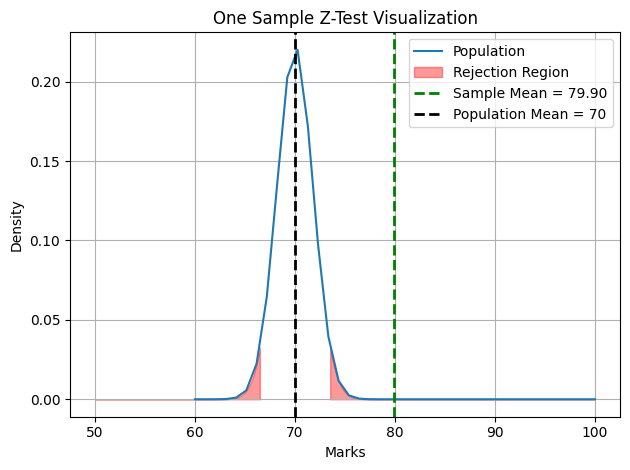

In [15]:
# Visualization

x = np.linspace(60,100,40)
std_error = sample_std / np.sqrt(n)
y = stats.norm.pdf(x, population_mean, std_error)

plt.plot(x, y, label='Population')

# Shade rejection regions
critical_value = stats.norm.ppf(0.975)
x_left  = np.linspace(50, population_mean - critical_value * (sample_std / np.sqrt(n)), 100)
x_right = np.linspace(population_mean + critical_value * (sample_std / np.sqrt(n)), 100, 100)

plt.fill_between(x_left,  stats.norm.pdf(x_left,  population_mean, sample_std/np.sqrt(n)), color="red", alpha=0.4, label="Rejection Region")
plt.fill_between(x_right, stats.norm.pdf(x_right, population_mean, sample_std/np.sqrt(n)), color="red", alpha=0.4)

# Mark sample mean
plt.axvline(sample_mean,     color="green", linestyle="--", linewidth=2, label=f"Sample Mean = {sample_mean:.2f}")
plt.axvline(population_mean, color="black", linestyle="--", linewidth=2, label=f"Population Mean = {population_mean}")

plt.title("One Sample Z-Test Visualization")
plt.xlabel("Marks")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Two Sample Z-Test

**Question:**
Are the marks of Section A students significantly
different from Section B students?

**H0:** Mean of Section A = Mean of Section B
**H1:** Mean of Section A ≠ Mean of Section B

In [16]:
section_A = np.random.randint(60, 100, 30)
section_B = np.random.randint(60, 100, 30)

print("Section A Marks:", section_A)
print("Section B Marks:", section_B)

Section A Marks: [68 85 61 79 87 66 67 94 73 76 95 99 63 61 65 63 88 77 85 93 69 95 73 90
 74 67 73 82 99 80]
Section B Marks: [75 77 83 85 84 88 74 60 84 66 68 83 60 67 83 70 76 67 94 94 92 64 98 87
 66 68 67 71 93 92]


In [18]:
z_stat, p_val = ztest(section_A, section_B)

print(f"Z-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")

if p_val < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

Z-Statistic : 0.1210
P-Value     : 0.9037
Accept H0


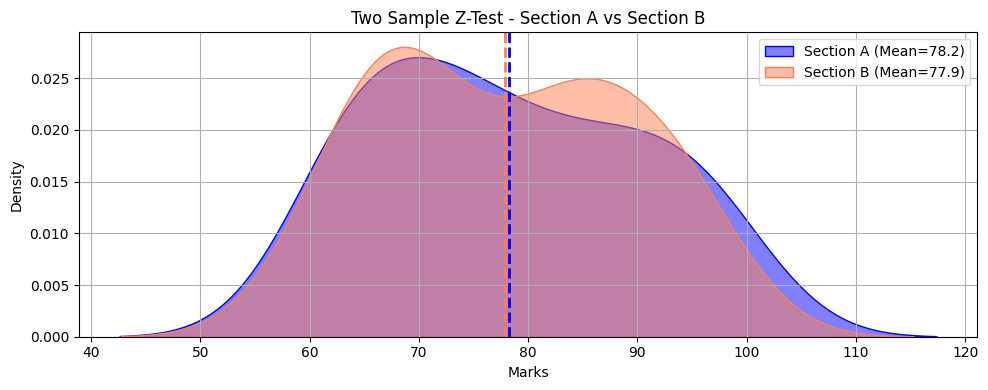

In [22]:
# visualization

plt.figure(figsize=(10, 4))

sns.kdeplot(section_A, fill=True, color="blue",  alpha=0.5, label=f"Section A (Mean={np.mean(section_A):.1f})")
sns.kdeplot(section_B, fill=True, color="coral", alpha=0.5, label=f"Section B (Mean={np.mean(section_B):.1f})")

plt.axvline(np.mean(section_A), color="blue",  linestyle="--", linewidth=2)
plt.axvline(np.mean(section_B), color="coral", linestyle="--", linewidth=2)

plt.title("Two Sample Z-Test - Section A vs Section B")
plt.xlabel("Marks")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is Z-Test and When to use it
- Hypothesis (H0 and H1)
- Z-Score Formula
- One Sample Z-Test (Self Made Dataset)
- Two Sample Z-Test (Self Made Dataset)
- Visualizations